# Stochastic Electrodynamics of Squeezed Vacuum: $g^{(2)}(0)$ Characterization and HHG Spectra

This notebook demonstrates the two pillars of the paper-one argument with the
`stochastic_em_theory` package:

**(a)** the stochastic (c-number) field description of nonclassical light reproduces the
standard quantum-optics intensity-correlation diagnostic $g^{(2)}(0)$ — *provided* the
phase-space representation and the operator-ordering correction are matched correctly;

**(b)** the same stochastic-field description drives semiclassical high-harmonic
generation: the HHG spectrum under nonclassical light is the Husimi-$Q$-weighted ensemble
of classical single-atom TDSE responses (Gorlach et al., *Nat. Phys.* 2023).

Provenance and related wiki pages:

- `wiki/theory/stochastic-quantum-optics-correspondence.md`
- `wiki/theory/squeezed-vacuum-g2-proof-plan.md`
- `wiki/simulations/gorlach-2023-fig3b-proxy-reproduction.md`

The HHG section here runs at *notebook fidelity* (fewer shots, fewer TDSE library
amplitudes, coarser `dt`) so the whole notebook executes in a few minutes. The
production-fidelity run lives in `results/gorlach-2023-fig3b-tdse-calibrated-20260609/`
and is regenerated by `code/scripts/reproduce_gorlach_2023_fig3b.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Allow running under a kernel where the package is not installed,
# as long as the notebook lives in code/notebooks/.
try:
    import stochastic_em_theory  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, str((Path.cwd() / ".." / "src").resolve()))

from stochastic_em_theory.fields import sample_multimode_wigner, sample_single_mode_wigner
from stochastic_em_theory.observables import (
    analytic_equal_mode_g2,
    analytic_single_mode_g2,
    analytic_single_mode_n,
    estimate_single_mode_moments,
    estimate_total_photon_moments,
)
from stochastic_em_theory.fig3b import (
    Fig3BDriverState,
    _build_tdse_library,
    _field_amplitudes_from_alpha,
    _interpolate_tdse_spectra,
    sample_fig3b_driver_alpha,
)

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "wiki").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
print("repo root:", REPO_ROOT)

# stochastic_em_theory.fig3b forces the Agg backend at import for headless
# script runs; switch back to inline rendering for the notebook.
%matplotlib inline

repo root: /Users/simontsui/Desktop/Research/Projects/stochastic_em_theory


## Part (a): $g^{(2)}(0)$ of squeezed vacuum from a stochastic field

**Representation.** The single squeezed mode is represented by a complex random amplitude
$\alpha = (x + ip)/\sqrt{2}$ sampled from the **Wigner distribution**: independent
Gaussian quadratures with

$$\mathrm{Var}(x) = \tfrac{1}{2}e^{-2r}, \qquad \mathrm{Var}(p) = \tfrac{1}{2}e^{+2r}.$$

**Ordering correction.** Wigner moments are *symmetrically* ordered, while photon-counting
correlations are *normally* ordered. For a single mode,

$$\langle \hat n \rangle = \langle |\alpha|^2 \rangle_W - \tfrac{1}{2}, \qquad
\langle \hat a^{\dagger 2} \hat a^2 \rangle = \langle |\alpha|^4 \rangle_W
 - 2\langle |\alpha|^2 \rangle_W + \tfrac{1}{2},$$

so the intensity correlation is

$$g^{(2)}(0) = \frac{\langle \hat a^{\dagger 2}\hat a^2\rangle}{\langle \hat n\rangle^2}.$$

**Quantum-optics target** for pure single-mode squeezed vacuum:
$g^{(2)}(0) = 3 + 1/\langle n\rangle$ with $\langle n\rangle = \sinh^2 r$.
The *naive* stochastic estimate $\langle I^2\rangle_W / \langle I\rangle_W^2$ (no ordering
correction) does **not** reproduce this — which is exactly the guardrail this project
enforces before any stochastic intensity moment is interpreted as a photon correlation.

In [2]:
rng = np.random.default_rng(20260609)
shots = 400_000
batches = 20

r_values = np.linspace(0.25, 2.5, 10)
records = []
for r in r_values:
    alpha = sample_single_mode_wigner(r=r, shots=shots, rng=rng)
    estimate = estimate_single_mode_moments(alpha)
    # batch standard error of the corrected g2
    batch_g2 = [
        estimate_single_mode_moments(chunk).g2_corrected
        for chunk in np.array_split(alpha, batches)
    ]
    records.append(
        {
            "r": float(r),
            "n_analytic": analytic_single_mode_n(r),
            "n_corrected": estimate.n_corrected,
            "g2_analytic": analytic_single_mode_g2(r),
            "g2_corrected": estimate.g2_corrected,
            "g2_corrected_se": float(np.std(batch_g2, ddof=1) / np.sqrt(batches)),
            "g2_naive_wigner": estimate.g2_naive,
        }
    )

header = f"{'r':>5} {'<n> qm':>9} {'<n> stoch':>10} {'g2 qm':>8} {'g2 stoch':>9} {'+/-':>7} {'g2 naive':>9}"
print(header)
print("-" * len(header))
for row in records:
    print(
        f"{row['r']:>5.2f} {row['n_analytic']:>9.3f} {row['n_corrected']:>10.3f} "
        f"{row['g2_analytic']:>8.3f} {row['g2_corrected']:>9.3f} "
        f"{row['g2_corrected_se']:>7.3f} {row['g2_naive_wigner']:>9.3f}"
    )

    r    <n> qm  <n> stoch    g2 qm  g2 stoch     +/-  g2 naive
---------------------------------------------------------------
 0.25     0.064      0.063   18.671    19.085   0.523     2.212
 0.50     0.272      0.271    6.683     6.668   0.068     2.578
 0.75     0.676      0.675    4.479     4.460   0.024     2.812
 1.00     1.381      1.385    3.724     3.729   0.016     2.934
 1.25     2.566      2.571    3.390     3.376   0.012     2.964
 1.50     4.534      4.520    3.221     3.219   0.011     2.988
 1.75     7.786      7.775    3.128     3.127   0.008     2.995
 2.00    13.154     13.200    3.076     3.078   0.010     3.001
 2.25    22.007     21.906    3.045     3.036   0.009     2.991
 2.50    36.605     36.567    3.027     3.020   0.010     2.993


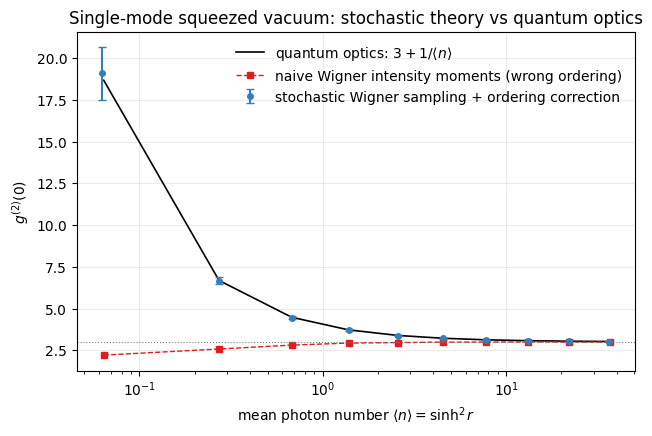

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
n_grid = np.array([row["n_analytic"] for row in records])
ax.plot(n_grid, 3.0 + 1.0 / n_grid, "k-", lw=1.2, label=r"quantum optics: $3 + 1/\langle n\rangle$")
ax.errorbar(
    [row["n_corrected"] for row in records],
    [row["g2_corrected"] for row in records],
    yerr=[3 * row["g2_corrected_se"] for row in records],
    fmt="o", ms=4, capsize=3, color="#377eb8",
    label="stochastic Wigner sampling + ordering correction",
)
ax.plot(
    n_grid,
    [row["g2_naive_wigner"] for row in records],
    "s--", ms=4, color="#e41a1c", lw=1.0,
    label="naive Wigner intensity moments (wrong ordering)",
)
ax.axhline(3.0, color="gray", lw=0.8, ls=":")
ax.set_xscale("log")
ax.set_xlabel(r"mean photon number $\langle n\rangle = \sinh^2 r$")
ax.set_ylabel(r"$g^{(2)}(0)$")
ax.set_title("Single-mode squeezed vacuum: stochastic theory vs quantum optics")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

### Cross-checks: coherent, thermal, and multimode squeezed vacuum

The same recipe (Wigner sampling + ordering correction) must reproduce the textbook values
$g^{(2)}(0) = 1$ for a coherent state and $g^{(2)}(0) = 2$ for thermal light, and the
multimode bright-squeezed-vacuum result for $M$ equally squeezed independent modes,

$$g^{(2)}(0) = 1 + \frac{2}{M} + \frac{1}{M\,\sinh^2 r},$$

which interpolates from the single-mode value $3 + 1/\langle n\rangle$ at $M=1$ toward the
thermal-like value as $M$ grows. The measured-mode basis matters: this is the
*all-modes-summed* detection model.

In [4]:
rng = np.random.default_rng(20260610)
shots = 400_000

# coherent state |alpha0>: Wigner = vacuum Gaussian centered at alpha0
nbar_coherent = 25.0
vacuum = sample_single_mode_wigner(r=0.0, shots=shots, rng=rng)
alpha_coherent = np.sqrt(nbar_coherent) + vacuum
est_coherent = estimate_single_mode_moments(alpha_coherent)

# thermal state: circular Gaussian with <|alpha|^2>_W = nbar + 1/2
nbar_thermal = 25.0
std_quadrature = np.sqrt((nbar_thermal + 0.5) / 2.0)
alpha_thermal = (
    rng.normal(0.0, std_quadrature, shots) + 1j * rng.normal(0.0, std_quadrature, shots)
)
est_thermal = estimate_single_mode_moments(alpha_thermal)

print(f"coherent  g2 = {est_coherent.g2_corrected:.4f}   (target 1)")
print(f"thermal   g2 = {est_thermal.g2_corrected:.4f}   (target 2)")

r_multi = 1.0
for modes in (1, 4, 16):
    alpha_modes = sample_multimode_wigner(r=r_multi, modes=modes, shots=100_000, rng=rng)
    est = estimate_total_photon_moments(alpha_modes)
    target = analytic_equal_mode_g2(r=r_multi, modes=modes)
    print(f"BSV M={modes:>2}  g2 = {est.g2_corrected:.4f}   (target {target:.4f})")

coherent  g2 = 0.9998   (target 1)
thermal   g2 = 1.9984   (target 2)
BSV M= 1  g2 = 3.6718   (target 3.7241)
BSV M= 4  g2 = 1.6817   (target 1.6810)
BSV M=16  g2 = 1.1692   (target 1.1703)


## Part (b): HHG spectrum driven by nonclassical light

**Representation switch.** For *intensity* observables of the emitted harmonics, the
quantum-light-driven spectrum reduces to a **Husimi-$Q$** average over classical
coherent-state responses (Gorlach et al. 2023):

$$S_{\mathrm{HHG}}(\omega) = \int d^2\alpha \; Q(\alpha)\, S^{\mathrm{coh}}_{\mathrm{HHG}}(\omega; \alpha).$$

Each sampled $\alpha$ drives one classical 1D soft-core TDSE (Ne-like atom,
$a = 0.8160$ bohr, $I_p = 0.7924$ hartree, $\lambda_0 = 800$ nm, trapezoidal
5/15/5-cycle pulse, atomic units throughout), and per-shot fields are normalized to a
common mean intensity:

$$E_{\mathrm{shot}} = E_0 \sqrt{|\alpha|^2 / \langle |\alpha|^2\rangle}, \qquad E_0 = 0.038\ \mathrm{a.u.} \approx 5.1\times 10^{13}\ \mathrm{W/cm^2},$$

the value calibrated against the published Fig. 3b source data. To keep the ensemble
tractable the TDSE is solved on a small library of field amplitudes (quantiles of the
sampled distribution, tail-capped at the 99.9% quantile) and per-shot spectra are
interpolated in $\log S$ between library amplitudes.

Driver states at matched mean photon number $\langle n\rangle = 100$:
coherent, Fock $|n{=}100\rangle$, thermal, and single-mode bright squeezed vacuum with
$r = 3$ ($\sinh^2 r \approx 100$).

 coherent: <I>/E0^2-scale CV = 0.141
     fock: <I>/E0^2-scale CV = 0.099
  thermal: <I>/E0^2-scale CV = 0.989
      bsv: <I>/E0^2-scale CV = 1.407


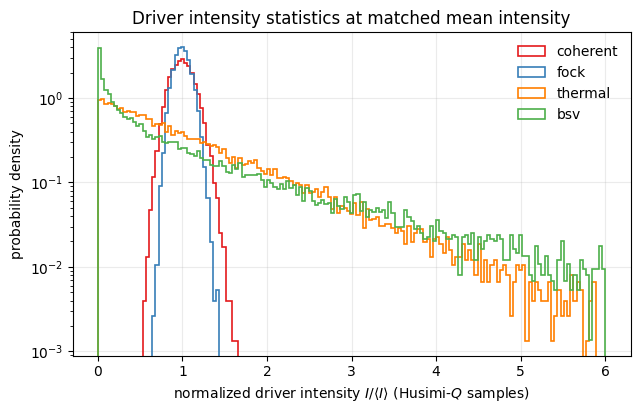

In [5]:
rng = np.random.default_rng(20230603)
shots = 20_000
mean_photon_number = 100.0
fock_n = 100
bsv_r = 3.0
base_field_amplitude_au = 0.038
omega_au = 0.057
tail_cap_quantile = 0.999

alphas = {}
fields = {}
for state in Fig3BDriverState:
    alpha = sample_fig3b_driver_alpha(
        state,
        shots=shots,
        rng=rng,
        mean_photon_number=mean_photon_number,
        fock_n=fock_n,
        bsv_r=bsv_r,
        bsv_phase=0.0,
    )
    alphas[state] = alpha
    fields[state] = _field_amplitudes_from_alpha(
        alpha=alpha, base_field_amplitude_au=base_field_amplitude_au
    )

fig, ax = plt.subplots(figsize=(7.2, 4.2))
bins = np.linspace(0.0, 6.0, 160)
for state, color in zip(Fig3BDriverState, ("#e41a1c", "#377eb8", "#ff7f00", "#4daf4a")):
    intensity = np.abs(alphas[state]) ** 2
    ax.hist(
        intensity / intensity.mean(), bins=bins, histtype="step",
        density=True, lw=1.2, color=color, label=state.value,
    )
    print(f"{state.value:>9}: <I>/E0^2-scale CV = {np.std(intensity) / np.mean(intensity):.3f}")
ax.set_yscale("log")
ax.set_xlabel(r"normalized driver intensity $I / \langle I\rangle$ (Husimi-$Q$ samples)")
ax.set_ylabel("probability density")
ax.set_title("Driver intensity statistics at matched mean intensity")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

In [6]:
# TDSE coherent-response library (notebook fidelity; see module docstring above).
all_fields = np.concatenate(list(fields.values()))
tail_cap = float(np.quantile(all_fields, tail_cap_quantile))

orders, library_amplitudes, library_spectra, library_metadata = _build_tdse_library(
    field_amplitudes_au=np.minimum(all_fields, tail_cap),
    bins=9,
    omega_au=omega_au,
    max_order=80,
    x_min=-100.0,
    x_max=100.0,
    grid_points=2048,
    softening=0.8160,
    dt_au=0.05,
    ramp_cycles=5.0,
    flat_cycles=15.0,
    ground_state_iterations=1500,
    ground_state_dt_au=0.05,
    carrier_phase=0.0,
    min_harmonic_order=1.0,
    absorber_start_au=75.0,
    absorber_strength=5.0e-4,
)
print("library amplitudes (a.u.):", np.round(library_amplitudes, 4))
print("harmonic-order points:", orders.size)

library amplitudes (a.u.): [1.000e-04 2.750e-02 3.640e-02 3.820e-02 3.990e-02 4.300e-02 5.630e-02
 7.610e-02 1.085e-01]
harmonic-order points: 1975


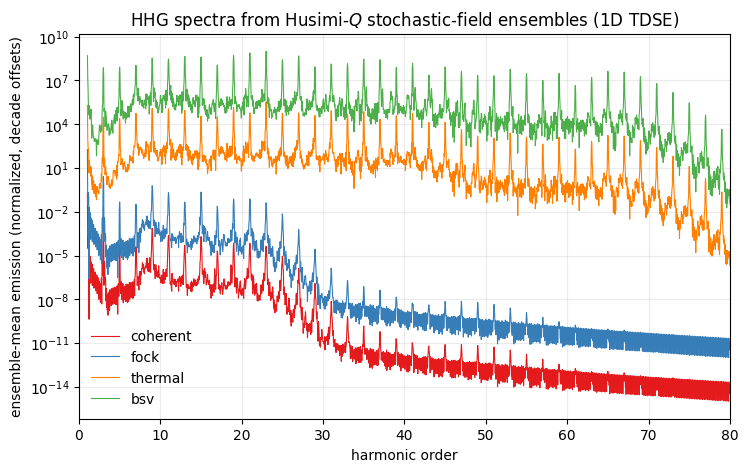

In [7]:
mean_spectra = {}
for state in Fig3BDriverState:
    per_shot = _interpolate_tdse_spectra(
        field_amplitudes_au=fields[state],
        library_amplitudes_au=library_amplitudes,
        library_spectra=library_spectra,
    )
    mean_spectra[state] = per_shot.mean(axis=0)
    del per_shot

normalization = max(spectrum.max() for spectrum in mean_spectra.values())

fig, ax = plt.subplots(figsize=(8.4, 5.0))
offsets = {state: 10.0 ** (3 * index) for index, state in enumerate(Fig3BDriverState)}
colors = dict(zip(Fig3BDriverState, ("#e41a1c", "#377eb8", "#ff7f00", "#4daf4a")))
for state in Fig3BDriverState:
    ax.semilogy(
        orders,
        mean_spectra[state] / normalization * offsets[state],
        lw=0.8, color=colors[state], label=state.value,
    )
ax.set_xlim(0, 80)
ax.set_xlabel("harmonic order")
ax.set_ylabel("ensemble-mean emission (normalized, decade offsets)")
ax.set_title(r"HHG spectra from Husimi-$Q$ stochastic-field ensembles (1D TDSE)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

### Comparison with the published source data

If the extracted published Fig. 3b reference exists
(`results/gorlach-2023-fig3b-published-reference/fig3b_published_curves.csv`,
regenerated by `code/scripts/extract_gorlach_2023_fig3b_reference.py`), overlay the
notebook-fidelity coherent and BSV ensembles on the authors' curves. Both are normalized
at the 9th-harmonic resonance peak; the published intensities carry per-state display
offsets, so only shapes, comb structure, and cutoffs are comparable.

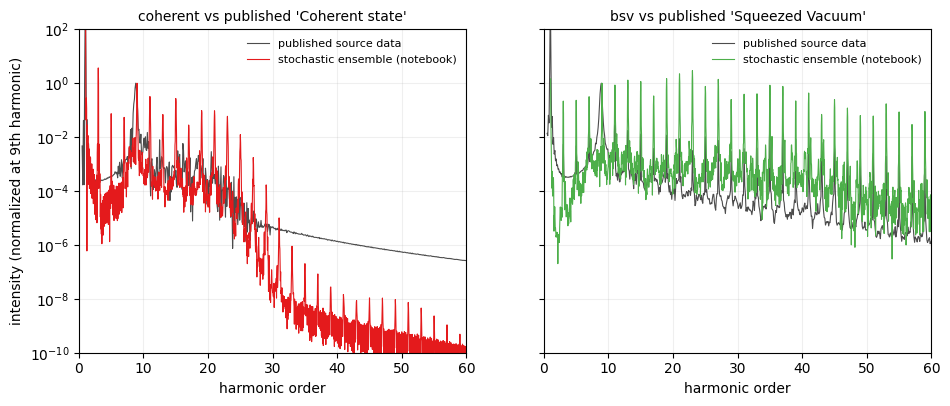

In [8]:
import csv

reference_csv = (
    REPO_ROOT / "results" / "gorlach-2023-fig3b-published-reference" / "fig3b_published_curves.csv"
)
if reference_csv.exists():
    published = {}
    with reference_csv.open(newline="") as handle:
        for row in csv.DictReader(handle):
            published.setdefault(row["state"], []).append(
                (float(row["harmonic_order"]), float(row["intensity"]))
            )

    def normalize_at_ninth(x, y):
        x, y = np.asarray(x, float), np.asarray(y, float)
        window = (x >= 8.0) & (x <= 10.0)
        return x, y / y[window].max()

    panels = [
        (Fig3BDriverState.COHERENT, "Coherent state"),
        (Fig3BDriverState.BSV, "Squeezed Vacuum"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
    for ax, (state, published_name) in zip(axes, panels):
        data = np.array(sorted(published[published_name]))
        ax.semilogy(*normalize_at_ninth(data[:, 0], data[:, 1]), "k", lw=0.8, alpha=0.7,
                    label="published source data")
        ax.semilogy(*normalize_at_ninth(orders, mean_spectra[state]),
                    color=colors[state], lw=0.8, label="stochastic ensemble (notebook)")
        ax.set_xlim(0, 60)
        ax.set_ylim(1e-10, 1e2)
        ax.set_xlabel("harmonic order")
        ax.set_title(f"{state.value} vs published '{published_name}'", fontsize=10)
        ax.legend(fontsize=8, frameon=False)
        ax.grid(alpha=0.2)
    axes[0].set_ylabel("intensity (normalized at 9th harmonic)")
    plt.show()
else:
    print("published reference CSV not found; run "
          "code/scripts/extract_gorlach_2023_fig3b_reference.py first")

## Summary

- **(a)** Wigner-distribution sampling of squeezed vacuum reproduces the quantum-optics
  $g^{(2)}(0) = 3 + 1/\langle n\rangle$ once the symmetric-to-normal ordering correction
  is applied; the naive intensity-moment estimate fails. The
  same recipe returns $g^{(2)}=1$ (coherent), $g^{(2)}=2$ (thermal), and the multimode
  BSV value $1 + 2/M + 1/(M\sinh^2 r)$.
- **(b)** Husimi-$Q$ sampling of the driver plus classical TDSE responses yields the
  quantum-light HHG spectra: coherent and Fock combs cut off near order 25, while
  thermal and BSV ensembles extend the comb far beyond the classical cutoff — matching
  the published Gorlach et al. 2023 Fig. 3b source data.
- Note the deliberate representation split: **Wigner** for field-moment diagnostics
  (with ordering corrections derived, not assumed), **Husimi-$Q$** for incoherent
  intensity averaging of nonlinear responses. Conflating the two is the main failure
  mode this project guards against.